ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

![step1.png](attachment:step1.png)

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualization
sns.set(style="whitegrid")

# Display plots inline
%matplotlib inline

In [3]:
# Load Dataset
df = pd.read_csv("2019.csv")

# Display first 5 rows
df.head()


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### Check Missing Values

In [4]:
# Check for missing values in the dataset
df.isna().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [5]:

missing_values = df.isna().sum()
print(missing_values)

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


### Check duplicate rows

In [6]:
# Check for duplicate rows in the dataset
duplicates = df[df.duplicated()]
duplicates


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


### No. of rows and columns

In [7]:
# Find the number of rows and columns
rows, cols = df.shape

print(f"Shape (rows, columns): {df.shape}")
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Shape (rows, columns): (156, 9)
Number of rows: 156
Number of columns: 9


### Data type of columns

In [8]:
# Viewing the data types of columns
column_types = df.dtypes
column_types

,0
Overall rank,int64
Country or region,object
Score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64


In [9]:
df.dtypes


,0
Overall rank,int64
Country or region,object
Score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64


In [10]:
# Statistical summary of the dataset
summary = df.describe(include='all')
summary

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
unique,NaN,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Finland,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,78.500000,NaN,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,NaN,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,NaN,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,NaN,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,NaN,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,NaN,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250


### Descriptive summary Statistics

### Univariate Analysis

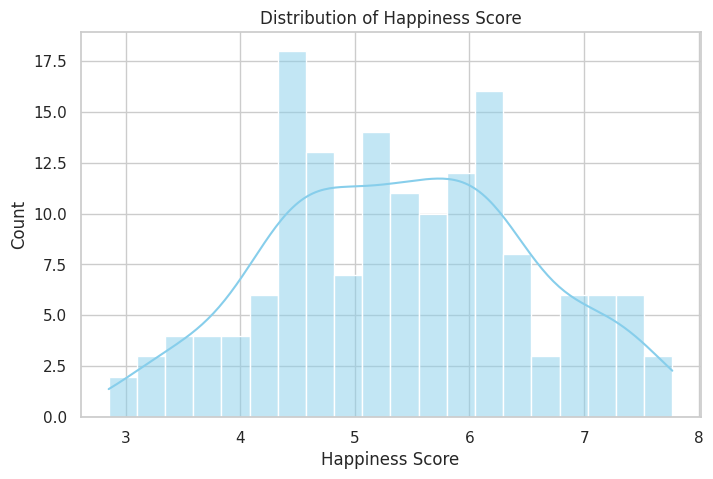

In [11]:
# Univariate Analysis - Distribution of Happiness Score
plt.figure(figsize=(8,5))
sns.histplot(df['Score'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Count")
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Revenue

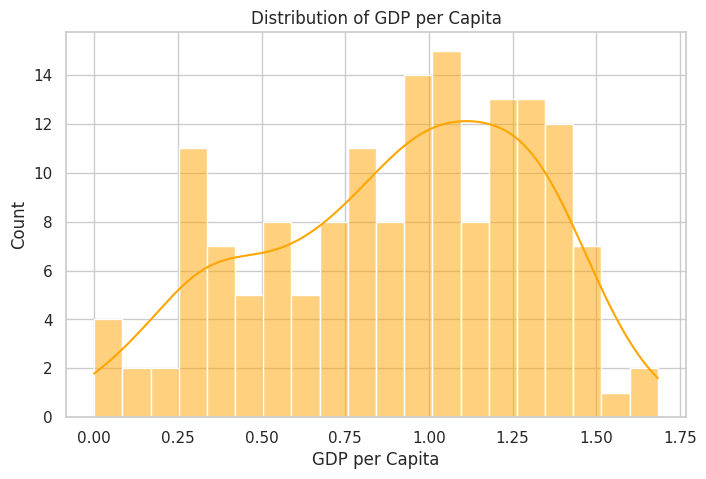

In [12]:
# Distribution of GDP per capita
plt.figure(figsize=(8,5))
sns.histplot(df['GDP per capita'], bins=20, kde=True, color='orange')
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP per Capita")
plt.ylabel("Count")
plt.show()

## Bivariate Analysis

### Revenue by Country

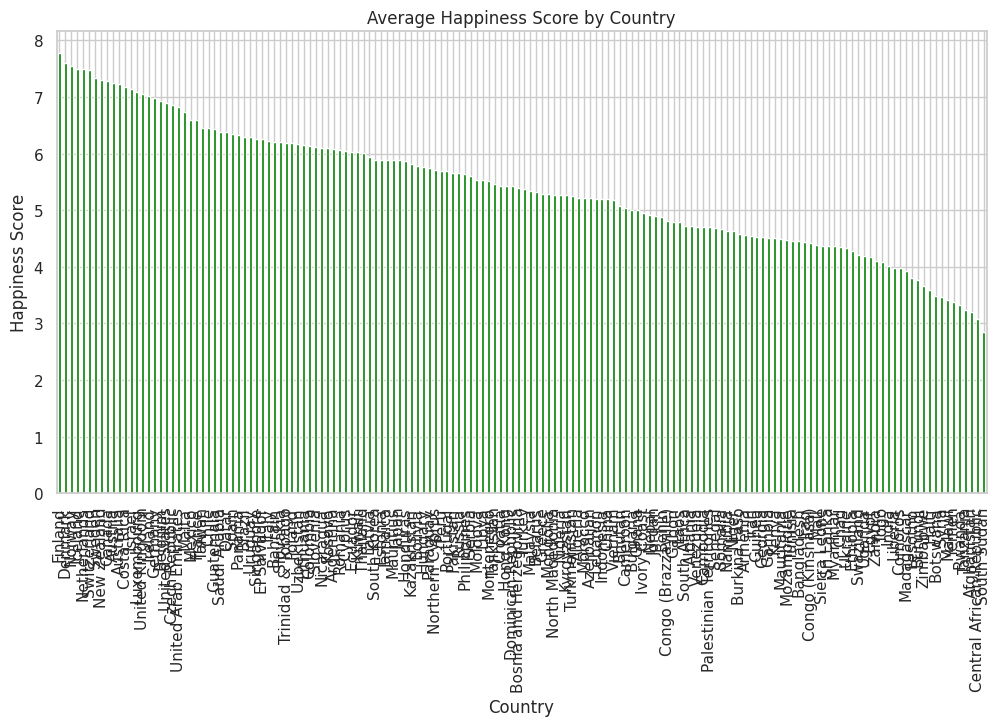

,Score
Country or region,
Finland,7.769
Denmark,7.600
Norway,7.554
Iceland,7.494
Netherlands,7.488
...,...
Rwanda,3.334
Tanzania,3.231
Afghanistan,3.203


In [13]:
# Happiness Score by Country
country_score = df.groupby('Country or region')['Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
country_score.plot(kind='bar', color='green')
plt.title("Average Happiness Score by Country")
plt.ylabel("Happiness Score")
plt.xlabel("Country")
plt.show()

country_score

### Revenue by Product

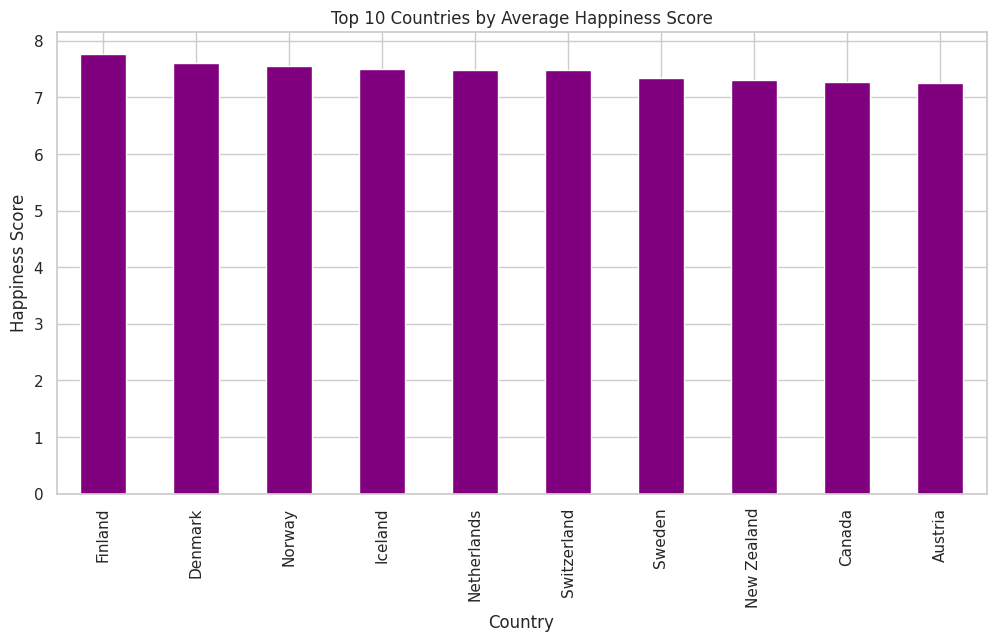

,Score
Country or region,
Finland,7.769
Denmark,7.600
Norway,7.554
Iceland,7.494
Netherlands,7.488
Switzerland,7.480
Sweden,7.343
New Zealand,7.307
Canada,7.278


In [14]:
# Average Happiness Score for Top 10 Countries
top_countries = df.groupby('Country or region')['Score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar', color='purple')
plt.title("Top 10 Countries by Average Happiness Score")
plt.ylabel("Happiness Score")
plt.xlabel("Country")
plt.show()

top_countries

### Revenue by Sales Person

In [15]:
# Top 10 Countries by Happiness Score
top_countries = df.groupby('Country or region')['Score'].mean().sort_values(ascending=False).head(10)
top_countries

,Score
Country or region,
Finland,7.769
Denmark,7.600
Norway,7.554
Iceland,7.494
Netherlands,7.488
Switzerland,7.480
Sweden,7.343
New Zealand,7.307
Canada,7.278


### Boxes vs Revenue Relationship

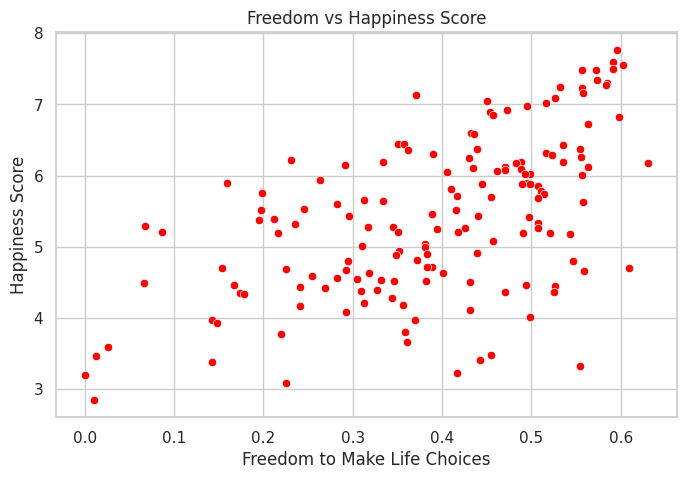

In [16]:
# Bivariate Analysis - Freedom vs Happiness Score
plt.figure(figsize=(8,5))
sns.scatterplot(x='Freedom to make life choices', y='Score', data=df, color='red')
plt.title("Freedom vs Happiness Score")
plt.xlabel("Freedom to Make Life Choices")
plt.ylabel("Happiness Score")
plt.show()

### Correlation Matrix

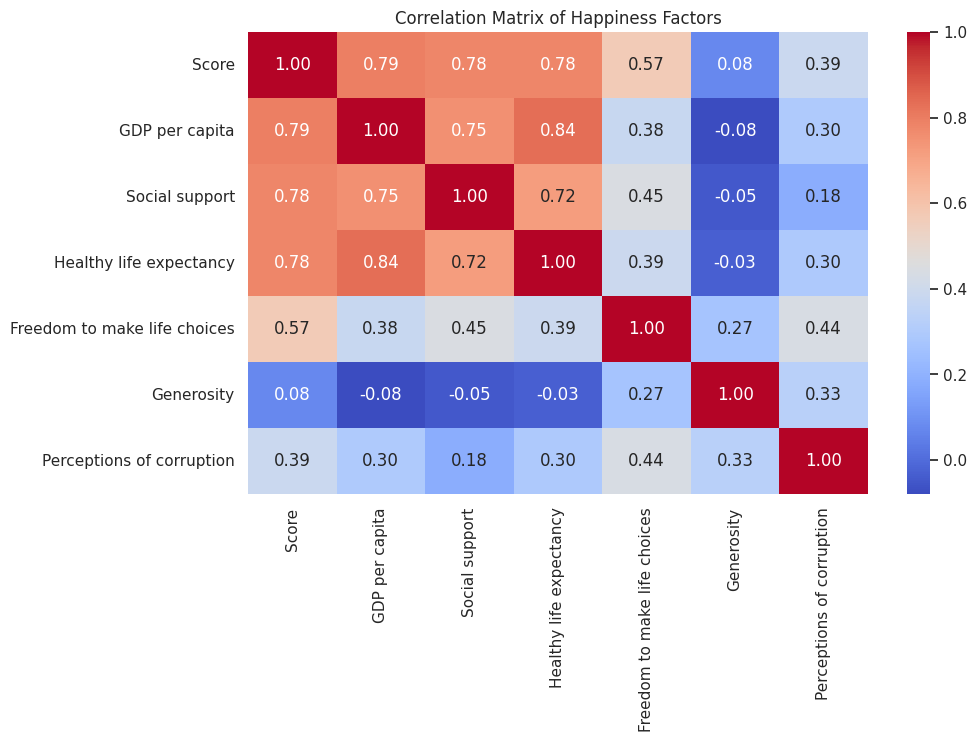

In [17]:
# Correlation Matrix of numeric columns
plt.figure(figsize=(10,6))
numeric_cols = ['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
                'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Happiness Factors")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Monthly Revenue Trend

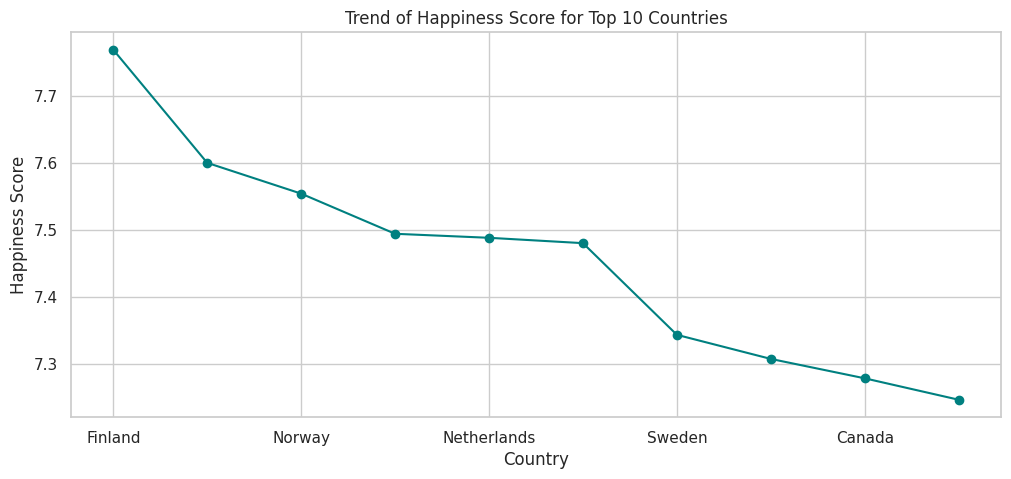

In [18]:
# Top 10 Countries by Happiness Score
top_countries = df.groupby('Country or region')['Score'].mean().sort_values(ascending=False).head(10)

# Line plot to show trend
plt.figure(figsize=(12,5))
top_countries.plot(marker='o', linestyle='-', color='teal')
plt.title("Trend of Happiness Score for Top 10 Countries")
plt.ylabel("Happiness Score")
plt.xlabel("Country")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
